In [5]:
""" 

Author: Ramesh Bhatta, Center of Imaging Science, RIT
Contact: rb1005@rit.edu

    - This code tests the performance of the Novel LAI estimation model (Bhatta et al.(2025)), modeled using simulated data, on the real LVIS waveforms and
    ground LAI-truth data from "Hemlock Sites" in Harvard Forest. This code also tests the performance of the model on "Deconvolved Waveform" data which is
    used to remove system contribution from raw waveform LiDAR and provide better structural representation of the underlying vegetation structure.

    - Note: The code may also be modified to be used for other waveform-LAI datasets by tweaking the relevant blocks within this code.

"""

## Importing necessary libraries

import h5py         # To read 'LVIS' waveform data
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer
from scipy.signal import find_peaks
import seaborn as sns


In [6]:
## A. Load LVIS waveforms

"""

    - We processed the raw LVIS waveforms earlier and  geolocated LAI data and saved them in .pkl file format for efficient memory management.
    This file contains all relevant waveform data along with geolocated LAI data. Please see below the content of the file. 
    - To know how the data was pre-processed and geolocated/temporally aligned LVIS waveform-LAI pair were obtained refer to:
        - 1. For detailed report see the "README.md" file. 
        - 2. "HF150_geolocator.py" file: This python file converts the raw "HEM" LAI data into geolocated data and generated geolocated files and visuals maps.
        - 3. "LVIS_FILTERING_SUMMER_MONTHS.py" file: Converts geolocated HF150 LAI data from 1. and matches with the nearest waveforms 
           to produce summary data files. Run this to extract major structural summary (such as rh100, total_energy) corresponding to each site in csv format. 
           Other required metrics can also be added by updating the code.
        - 4. "LVIS_FULL_WAVEFORMS_ALL_ATTRIBUTES.py" file: Similar to 2, but also saves whole raw waveform along with associated LAI values for modeling. 
           See result of this block (A) below to understand what the file generated from this code contains. Run this file to get raw full-waveform with all LVIS fields
           as shown below. 
        

"""

location = 'HEM' # We are using HEMLOCK plot LAI data only. 
pkl_file = f'lvis_waveforms_{location.lower()}.pkl'

with open(pkl_file, 'rb') as f:
    data = pickle.load(f)
    waveforms = data['waveforms']

print(f"Loaded {len(waveforms)} waveforms")

print(f"="*50)
print(f"See whats within the loaded Waveforms:")
print(f"="*50)
waveforms

Loaded 11 waveforms
See whats within the loaded Waveforms:


[{'shot_number': 2276855,
  'lai_value': np.float64(3.56),
  'distance_km': np.float64(0.000903937812418422),
  'SIGMEAN': 59.044921875,
  'AZIMUTH': 313.1104736328125,
  'INCIDENTANGLE': 1.609166145324707,
  'LFID': 1659432034,
  'RANGE': 12563.6943359375,
  'TIME': 50136.77245807648,
  'rxwave': array([61, 61, 60, ..., 59, 59, 59], dtype=uint16),
  'rxwave_length': 1024,
  'txwave': array([ 63,  62,  63,  63,  63,  65,  63,  62,  63,  62,  62,  61,  62,
          61,  61,  60,  61,  61,  62,  60,  60,  59,  61,  61,  61,  61,
          60,  58,  57,  59,  60,  62,  60,  61,  61,  59,  62,  60,  60,
          61,  62,  62,  60,  61,  60,  59,  59,  60,  61,  60,  61,  60,
          59,  60,  61,  62,  61,  61,  61,  62,  61,  61,  63,  63,  63,
          62,  63,  63,  65,  70,  74,  83,  94, 108, 128, 158, 198, 251,
         319, 393, 458, 513, 553, 563, 551, 520, 470, 417, 358, 301, 252,
         215, 187, 164, 144, 133, 120, 110, 100,  91,  84,  80,  75,  71,
          69,  68,  67

In [7]:
## See what are the fields within loaded data

example_waveform = waveforms[0]
print("Waveform keys:", example_waveform.keys())

Waveform keys: dict_keys(['shot_number', 'lai_value', 'distance_km', 'SIGMEAN', 'AZIMUTH', 'INCIDENTANGLE', 'LFID', 'RANGE', 'TIME', 'rxwave', 'rxwave_length', 'txwave', 'txwave_length'])



Checking: LVISC1B_GEDI2021_0806_R2112_049718.h5
No matching shots found in this file.

Checking: LVISC1B_GEDI2021_0806_R2112_051257.h5
Found 4 matching shots in this file.

Total extracted ground waveforms: 4
Successfully computed smoothed average bare-ground waveform!


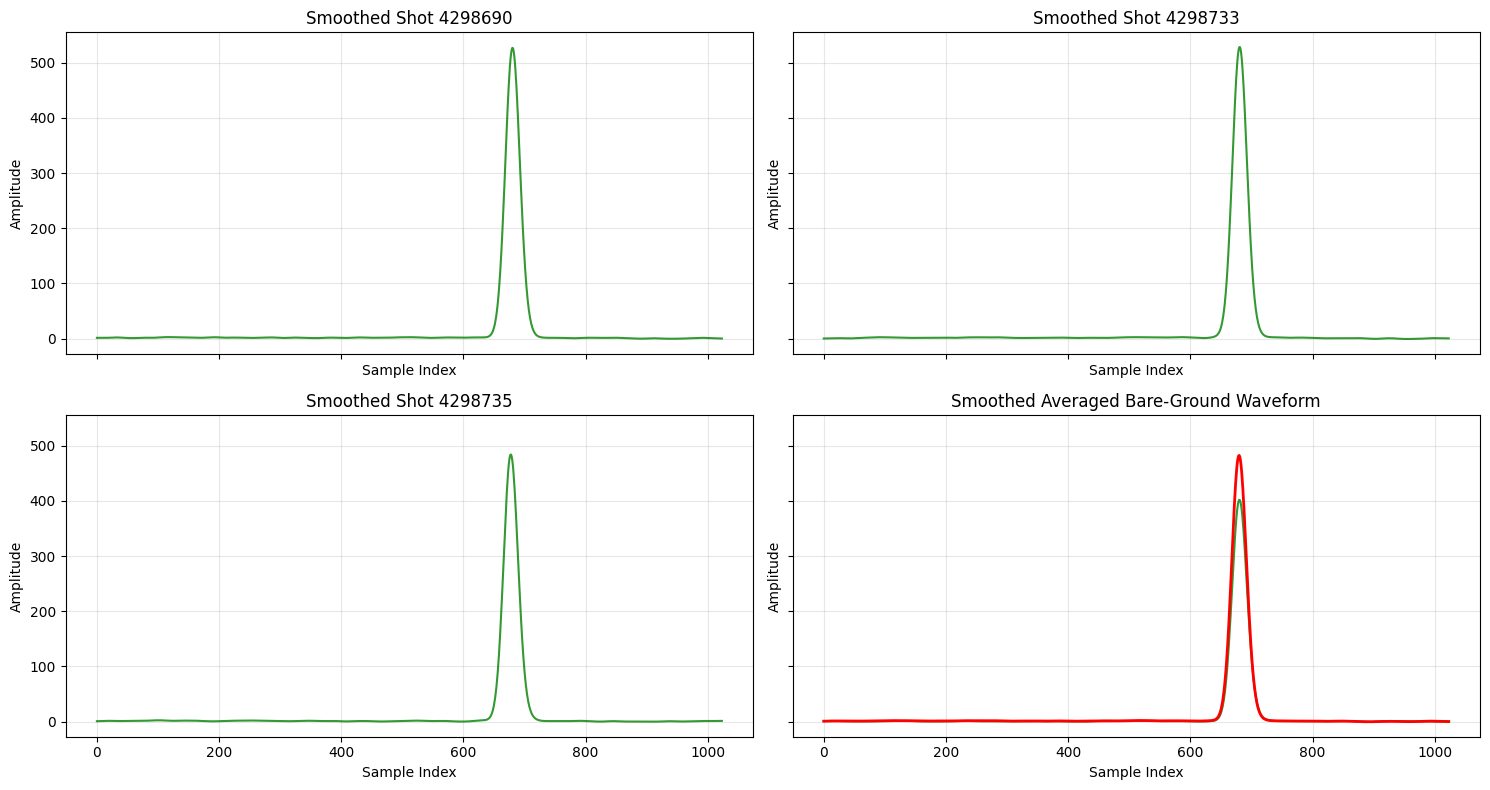

In [8]:
## B. To perform waveform deconvolution, import pure/bare ground return from the waveform;
## From "Qgis" we can see that the bare ground return have following shot number:

gnd_waveforms_shotnums = [4298690, 4298735, 4298733, 4299142, 4298690]

lvis_files = [
    'LVISC1B_GEDI2021_0806_R2112_049718.h5',
    'LVISC1B_GEDI2021_0806_R2112_051257.h5'
]

extracted_rx_waveforms = []
extracted_tx_waveforms = []
extracted_metadata = []

for lvis_file in lvis_files:
    print(f"\nChecking: {lvis_file}")
    
    try:
        with h5py.File(lvis_file, 'r') as lvis_hdf:
            # Load ONLY the shot numbers to find our targets
            shot_numbers = np.array(lvis_hdf['SHOTNUMBER'])
            
            # Create a mask to find where the shot numbers match our list
            mask = np.isin(shot_numbers, gnd_waveforms_shotnums)
            indices = np.where(mask)[0]
            
            if len(indices) > 0:
                print(f"Found {len(indices)} matching shots in this file.")
                
                # h5py requires indices to be sorted for direct extraction
                indices = np.sort(indices) 
                
                # Extract ONLY the required waveforms directly from disk
                rx_waves = lvis_hdf['RXWAVE'][indices]
                tx_waves = lvis_hdf['TXWAVE'][indices]
                
                extracted_rx_waveforms.extend(rx_waves)
                extracted_tx_waveforms.extend(tx_waves)
                
                # Extract metadata including SIGMEAN for noise removal
                for idx in indices:
                    metadata = {
                        'SHOTNUMBER': lvis_hdf['SHOTNUMBER'][idx],
                        'LAT0': lvis_hdf['LAT0'][idx],
                        'LON0': lvis_hdf['LON0'][idx],
                        'Z0': lvis_hdf['Z0'][idx],
                        'SIGMEAN': lvis_hdf['SIGMEAN'][idx],
                        'source_file': lvis_file
                    }
                    extracted_metadata.append(metadata)
            else:
                print("No matching shots found in this file.")
                
    except Exception as e:
        print(f"Error processing {lvis_file}: {e}")

# Convert lists to NumPy arrays
rx_array = np.array(extracted_rx_waveforms)
tx_array = np.array(extracted_tx_waveforms)

print(f"\nTotal extracted ground waveforms: {len(rx_array)}")

## Noise removal and Smoothing 
processed_rx_waveforms = []

for i, rxwave in enumerate(rx_array):
    # Get the specific noise floor for this shot
    sigmean = extracted_metadata[i]['SIGMEAN']
    
    # Remove noise
    rx_clean = np.array(rxwave - sigmean, dtype=np.float64)
    smoothed = gaussian_filter1d(rx_clean, sigma=10.0)
    processed_rx_waveforms.append(smoothed)

processed_rx_array = np.array(processed_rx_waveforms)

# Average the processed waveforms 
if len(processed_rx_array) > 0:
    # Average across the smoothed/denoised shots
    smoothed_avg_bare_ground_rx = np.mean(processed_rx_array, axis=0)  
    avg_bare_ground_tx = np.mean(tx_array, axis=0) 
    df_ground_shots = pd.DataFrame(extracted_metadata)
    
    print("Successfully computed smoothed average bare-ground waveform!")
else:
    print("Could not compute average: no waveforms found.")

## Visualize all these waveforms:

# Create a 2x2 grid for the 3 individual processed shots + 1 averaged shot
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

# Plot the 3 individual processed ground return waveforms
for i, proc_wave in enumerate(processed_rx_array):
    shotnum = extracted_metadata[i]['SHOTNUMBER']
    axes[i].plot(proc_wave, color='g', alpha=0.8)
    axes[i].set_title(f'Smoothed Shot {shotnum}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
axes[3].plot(smoothed_avg_bare_ground_rx, color='r', linewidth=2)
axes[3].set_title('Smoothed Averaged Bare-Ground Waveform')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlabel('Sample Index')
axes[3].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()


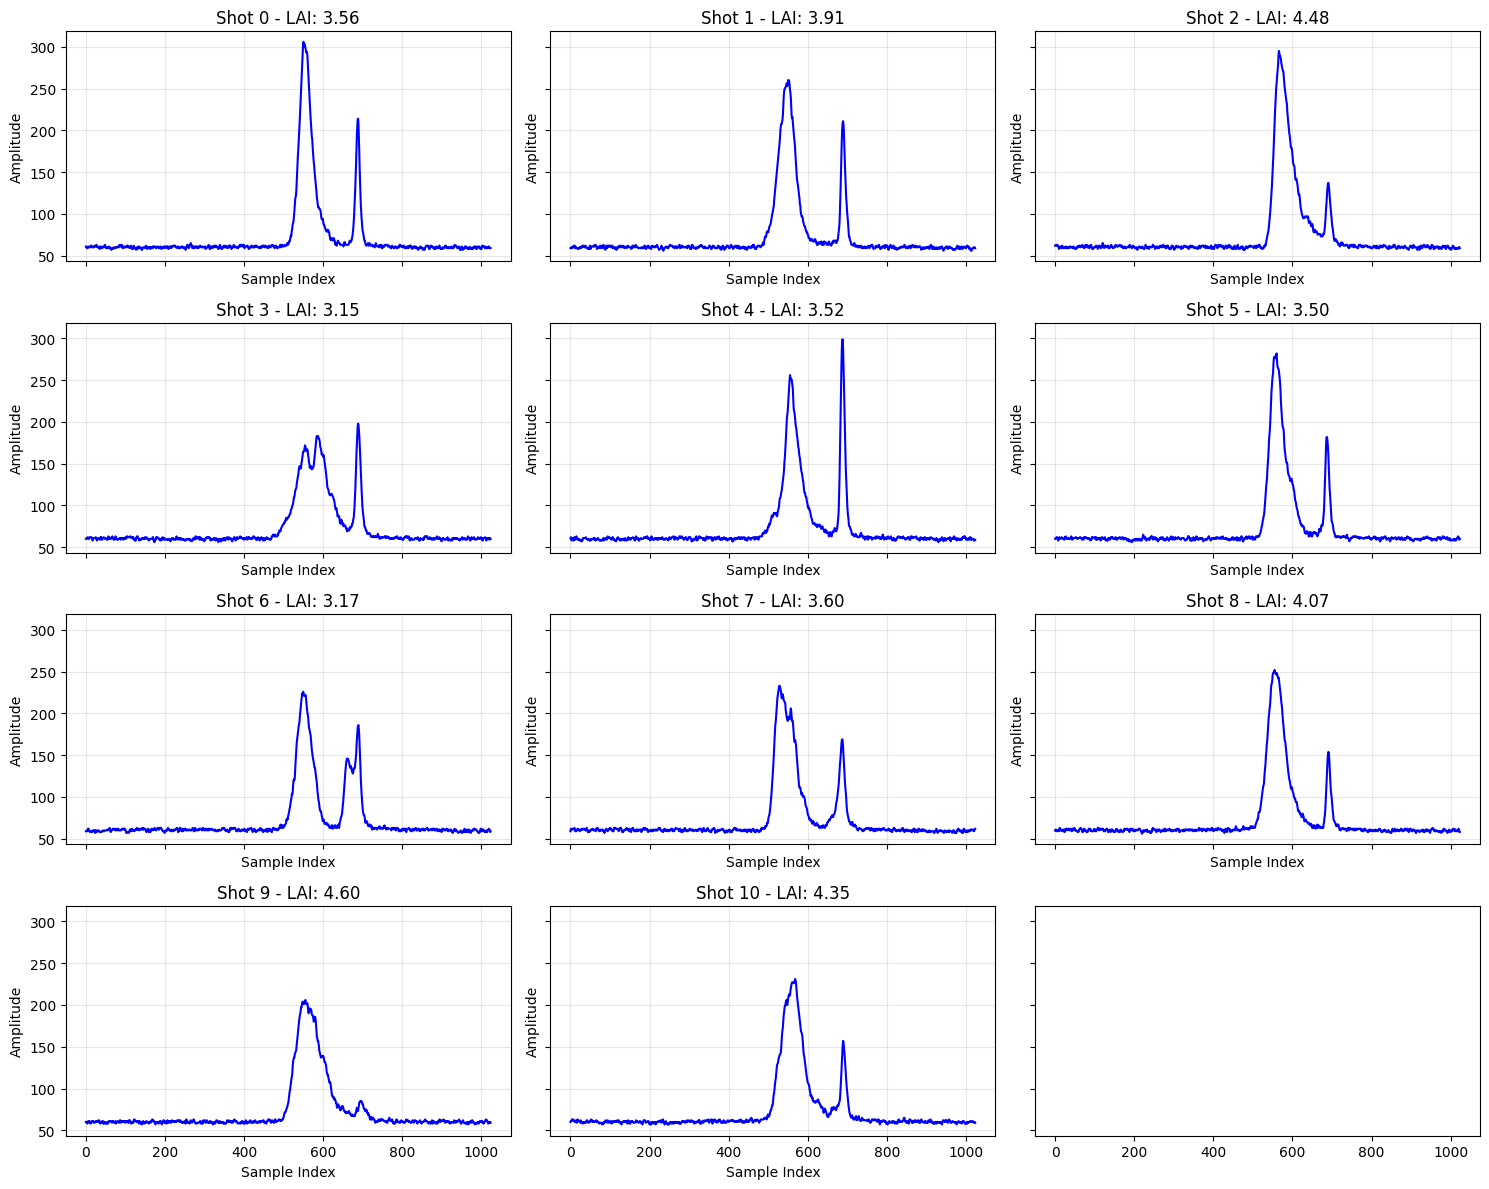

In [9]:
## C. Visualize the raw waveforms along with LAI values

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, wf in enumerate(waveforms):
    rxwave = np.array(wf['rxwave'], dtype=np.float64)
    lai_value = wf['lai_value']
    axes[i].plot(rxwave, color='b')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()


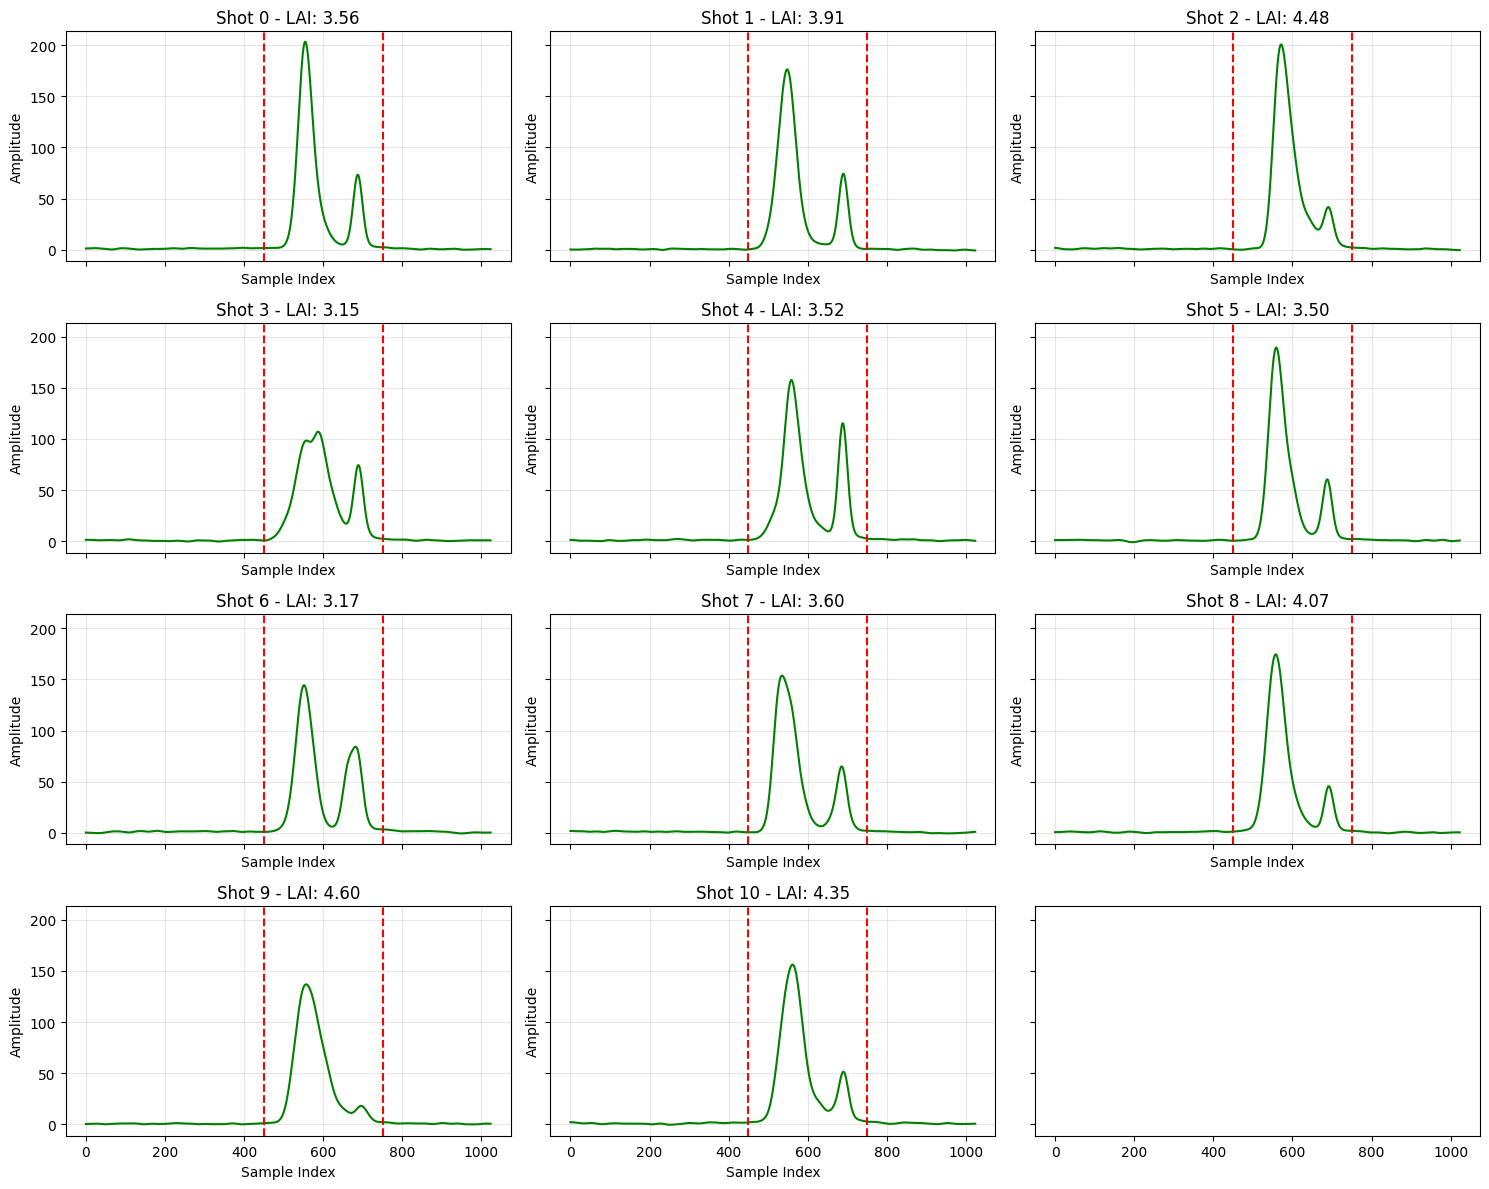

In [10]:
## D. Remove Noise from the raw waveforms for LAI modeling

# Smooth and clip noise
processed = []
lai_values = []

for wf in waveforms:
    rxwave = np.array(wf['rxwave']- wf['SIGMEAN'], dtype=np.float64)
    
    # Smooth
    smoothed = gaussian_filter1d(rxwave, sigma=10.0)
    processed.append(smoothed)

processed = np.array(processed)

# Plot processed waveforms with LAI labels
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (wf, proc) in enumerate(zip(waveforms, processed)):
    lai_value = wf['lai_value']
    lai_values.append(lai_value)
    axes[i].plot(proc, color='g')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [11]:
len(processed)

11


Starting Gold Deconvolution...
Deconvolution complete, plotting the deconvolved waveforms...


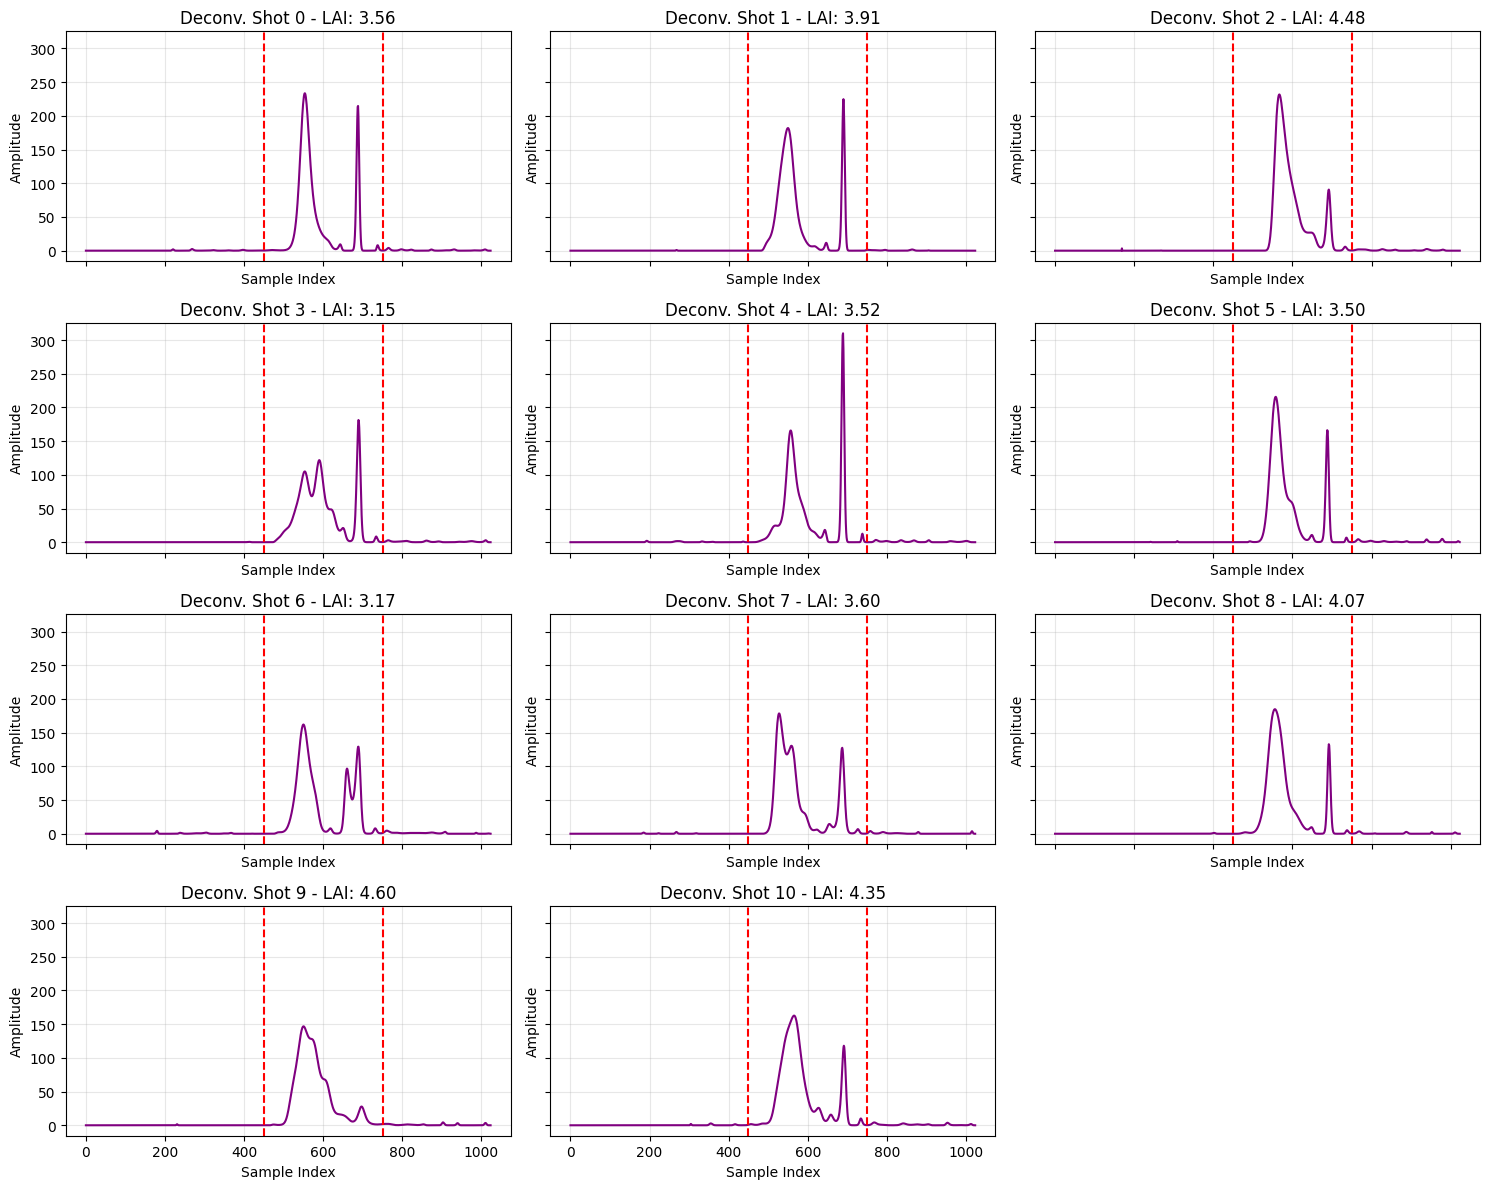

In [12]:
## E. One-Fold Gold-Deconvolution Algorithm:
#  To extract deconvolved waveform using raw smoothed waveforms contained in "processed" array and 
# using "smoothed_avg_bare_ground_rx" as system contribution / system response term and save it in "processed_deconvolved_gold" array.

# Helper function to manually shift the deconvolved signal to correct for alignment
def manual_shift(signal, shift):
    """Manually shift a 1D signal."""
    return np.roll(signal, shift)

# Construct the Response matrix (H) for convolution
def response_matrix(h, len_x):
    """Creates a Response matrix from the filter h for convolution."""
    len_h = len(h)
    H = np.zeros((len_x + len_h - 1, len_x))
    for i in range(len_x): 
        H[i:i + len_h, i] = h
    return H

# Define Boosted one fold gold deconvolution algorithm
def boosted_gold_deconvolution(P_t, R_t, num_iterations=10, num_repetitions=5, boosting_coefficient=1.25, positivity=True):
    y = P_t
    
    # Pad y dynamically so its length perfectly matches H.T's expected dimensions
    target_len = len(P_t) + len(R_t) - 1
    pad_total = target_len - len(P_t)
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left
    y_padded = np.pad(y, (pad_left, pad_right), mode='constant')
    
    # Create matrix H from R_t
    H = response_matrix(R_t, len(P_t))
    
    # Calculate y' = H^T y
    y_prime = H.T @ y_padded
    H_T_H = H.T @ H

    # Initial value of P_delta 
    P_delta = np.ones_like(P_t)

    # Repeat for each repetition
    for r in range(num_repetitions):
        # Repeat for 'n' iterations
        for i in range(num_iterations):
            # Added a tiny epsilon (1e-10) to the denominator to prevent division by zero warnings
            denominator = H_T_H @ P_delta
            denominator[denominator == 0] = 1e-10 
            
            P_delta_est = y_prime / denominator 
            P_delta_new = P_delta_est * P_delta
            P_delta = P_delta_new
            
            # Enforce positivity constraint if enabled
            if positivity:
                P_delta = np.maximum(P_delta, 0)

        if r < num_repetitions - 1:
            P_delta = np.power(P_delta, boosting_coefficient)

    # Energy-based post-scaling to match the original signal energy
    def apply_energy_scaling(P_delta_t_est, P_t):
        energy_P_t = np.sum(np.abs(P_t) ** 2)
        energy_P_delta_t_est = np.sum(np.abs(P_delta_t_est) ** 2)
        scale_factor = np.sqrt(energy_P_t / energy_P_delta_t_est) if energy_P_delta_t_est > 0 else 1.0
        return P_delta_t_est * scale_factor

    # Apply energy-based post-scaling
    P_delta_scaled = apply_energy_scaling(P_delta, P_t)
    
    # Cross-correlation to estimate the shift between P(t) and deconvolved P_delta
    cross_corr = np.correlate(P_t, P_delta_scaled, mode='full')
    shift_index = np.argmax(cross_corr) - len(P_t) + 1
    
    # Apply manual shift to correct alignment using np.roll
    P_delta_shifted = manual_shift(P_delta_scaled, shift=shift_index)
    
    return P_delta_shifted


# Execute
processed_deconvolved_gold = []

print("\nStarting Gold Deconvolution...")
for i, proc_wave in enumerate(processed):
    # Running the deconvolution with boosting_coefficient=1 i.e. no boosting
    deconv_wave = boosted_gold_deconvolution(
        P_t=proc_wave, 
        R_t=smoothed_avg_bare_ground_rx, 
        num_iterations=500,      
        num_repetitions=1, 
        boosting_coefficient=1, 
        positivity=True
    )
    processed_deconvolved_gold.append(deconv_wave)

processed_deconvolved_gold = np.array(processed_deconvolved_gold)
print("Deconvolution complete, plotting the deconvolved waveforms...")

# Plot the results
# Plot deconvolved waveforms with LAI labels
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (wf, deconv) in enumerate(zip(waveforms, processed_deconvolved_gold)):
    lai_value = wf['lai_value']
    axes[i].plot(deconv, color='purple')
    axes[i].set_title(f'Deconv. Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
if len(processed_deconvolved_gold) < len(axes):
    for j in range(len(processed_deconvolved_gold), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


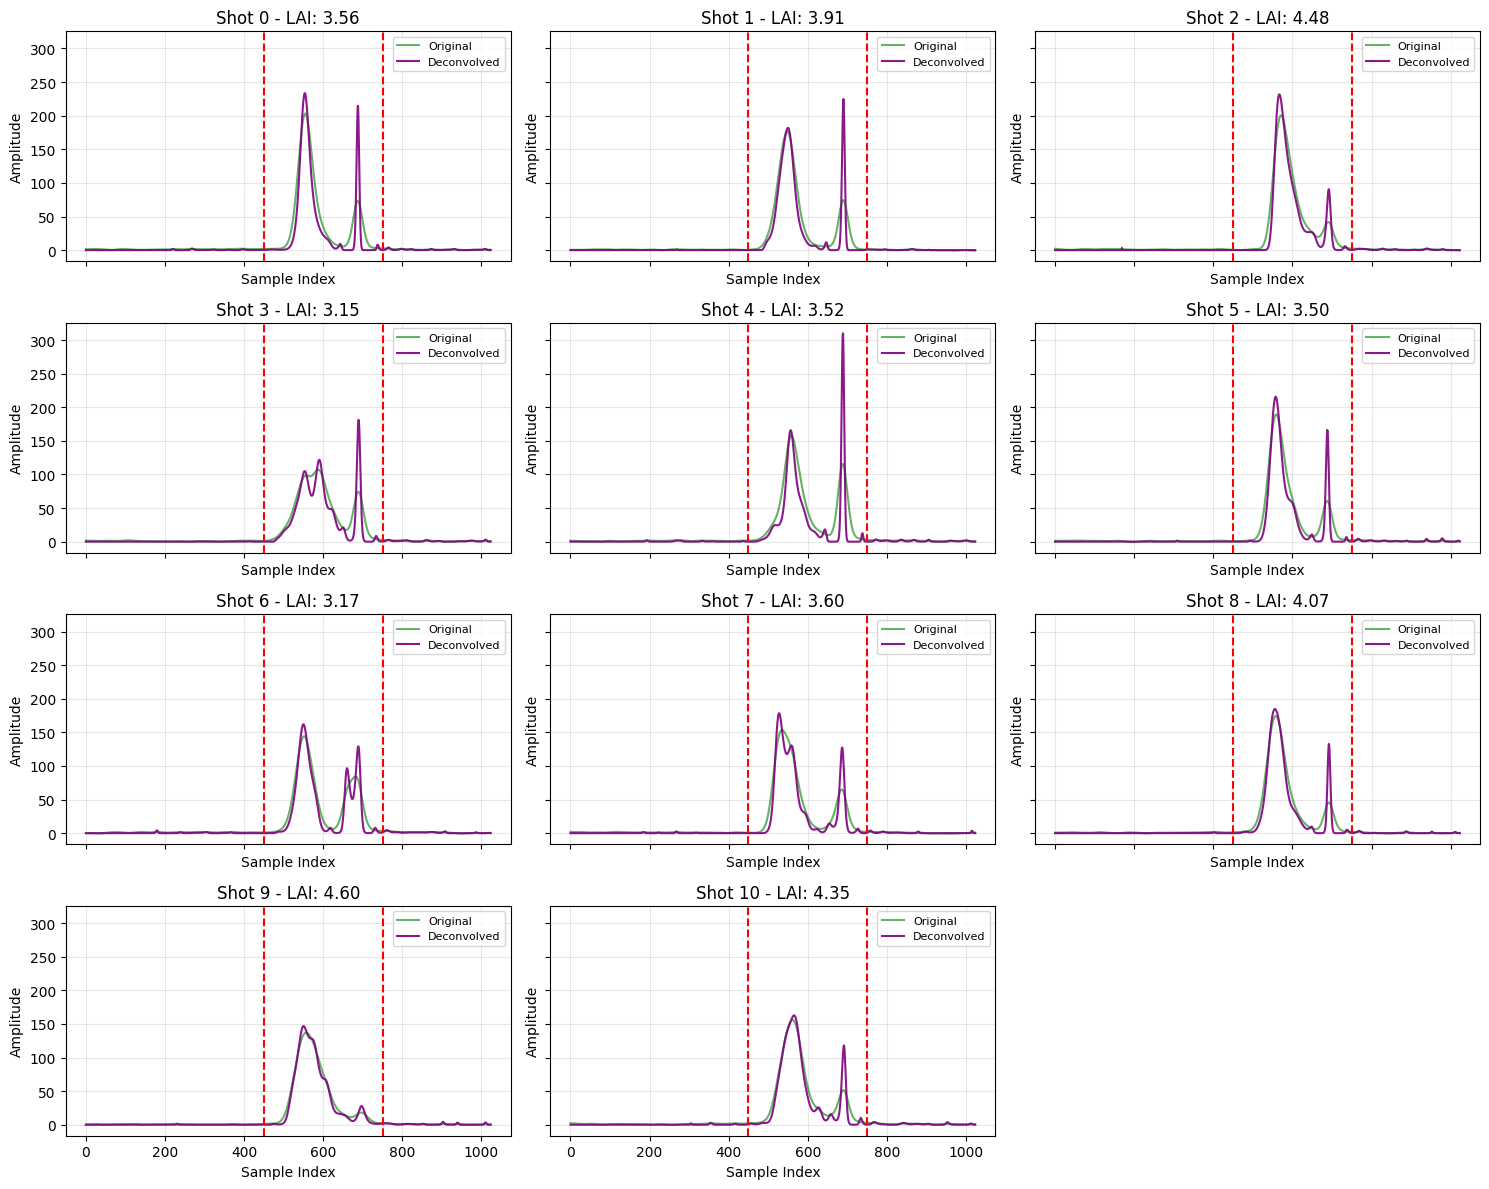

In [13]:
## Plot deconvolved waveforms along with raw waveforms with LAI labels to see how the deconvolution worked.

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()
for i, (wf, orig_wave, deconv) in enumerate(zip(waveforms, processed, processed_deconvolved_gold)):
    lai_value = wf['lai_value']
    axes[i].plot(orig_wave, color='g', alpha=0.6, linewidth=1.5, label='Original')
    axes[i].plot(deconv, color='purple', alpha=0.9, linewidth=1.5, label='Deconvolved')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize=8)
if len(processed_deconvolved_gold) < len(axes):
    for j in range(len(processed_deconvolved_gold), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Starting Richardson-Lucy Deconvolution...
RL Deconvolution complete!


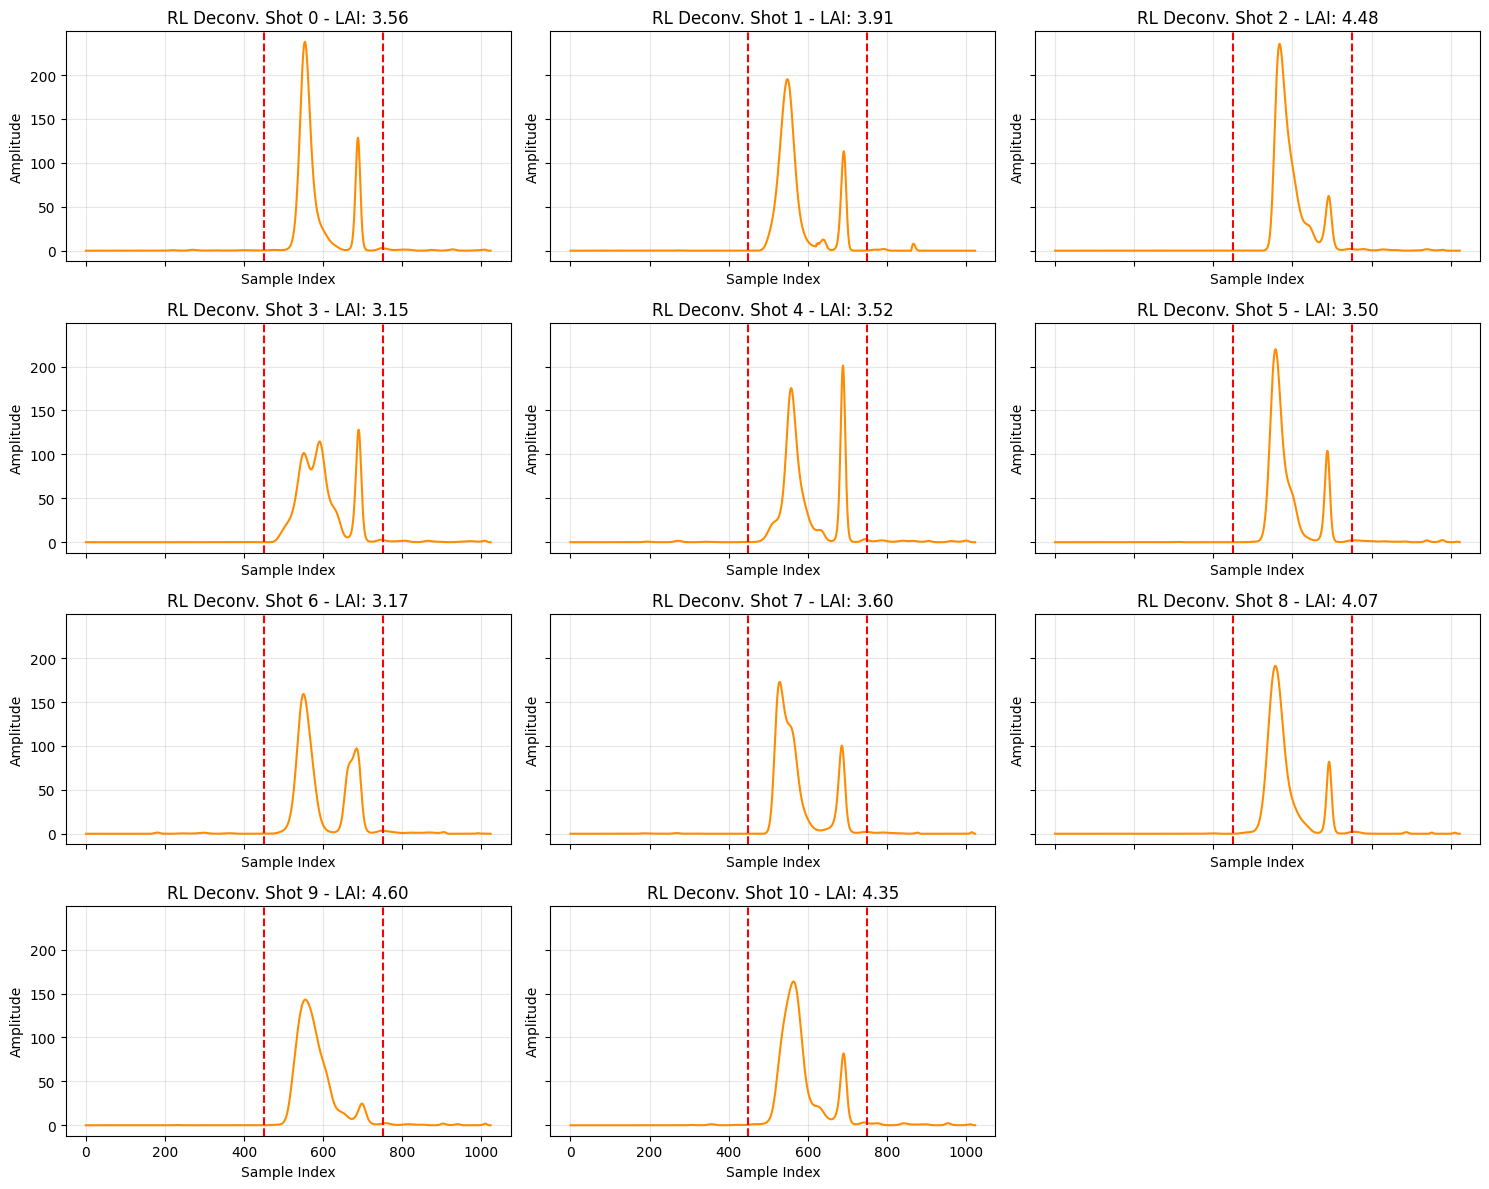

In [14]:
## F. Richardson-Lucy Algorithm for deconvolution:

# Define function
def richardson_lucy_deconvolution_boosted(P_t, R_t, num_iterations, num_repetitions, boosting_coefficient, positivity=True):
    """
    Apply the Richardson-Lucy deconvolution algorithm with boosting.
    """
    
    # Pad the observed waveform to reduce boundary effects
    pad_len = len(R_t) // 2
    P_t_padded = np.pad(P_t, pad_len, mode='constant')

    # Initialize the deconvolved signal with a flat guess (mean of signal is better than 1s)
    P_delta = np.ones_like(P_t_padded) * np.mean(P_t)

    for r in range(num_repetitions):
        # Iterate the RL algorithm
        for i in range(num_iterations):
            
            # Full convolution of the current estimate with the system response
            convolved = fftconvolve(P_delta, R_t, mode='same')
    
            # Compute the ratio P(t) / (R * P_delta)
            ratio = P_t_padded / (convolved + 1e-10)  # Avoid division by zero
    
            # Convolve the ratio with the flipped system response
            correction = fftconvolve(ratio, R_t[::-1], mode='same')
            P_delta *= correction
    
            # Enforce positivity constraint if enabled
            if positivity:
                P_delta = np.maximum(P_delta, 0)
        
        # After n iterations, apply the boosting function to the current solution
        if r < num_repetitions - 1:  
            P_delta = np.power(P_delta, boosting_coefficient)
            
    # Energy-based post-scaling to match the original signal energy
    def apply_energy_scaling(P_delta_t_est, P_t):
        energy_P_t = np.sum(np.abs(P_t) ** 2)
        energy_P_delta_t_est = np.sum(np.abs(P_delta_t_est) ** 2)
        scale_factor = np.sqrt(energy_P_t / energy_P_delta_t_est) if energy_P_delta_t_est > 0 else 1.0
        return P_delta_t_est * scale_factor

    # Trim the padded edges OFF first, before calculating energy scaling
    P_delta_trimmed = P_delta[pad_len:-pad_len]

    # Apply energy-based post-scaling
    P_delta_scaled = apply_energy_scaling(P_delta_trimmed, P_t)
    
    # Cross-correlation to estimate the shift between P(t) and deconvolved P_delta
    cross_corr = np.correlate(P_t, P_delta_scaled, mode='full')
    shift_index = np.argmax(cross_corr) - len(P_t) + 1
    
    # Apply manual shift to correct alignment
    P_delta_shifted = manual_shift(P_delta_scaled, shift=shift_index)
    
    return P_delta_shifted

# Execute 
processed_rl_deconvolved = []

print("\nStarting Richardson-Lucy Deconvolution...")
for i, proc_wave in enumerate(processed):
    # RL converges faster than Gold, 10-150 iterations is usually a good sweet spot
    deconv_wave = richardson_lucy_deconvolution_boosted(
        P_t=proc_wave, 
        R_t=smoothed_avg_bare_ground_rx, 
        num_iterations=25,      
        num_repetitions=1, 
        boosting_coefficient=1, 
        positivity=True
    )
    processed_rl_deconvolved.append(deconv_wave)

processed_deconvolved_rl = np.array(processed_rl_deconvolved)
print("RL Deconvolution complete!")

## Plot the results
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (wf, deconv) in enumerate(zip(waveforms, processed_deconvolved_rl)):
    lai_value = wf['lai_value']
    axes[i].plot(deconv, color='darkorange')
    axes[i].set_title(f'RL Deconv. Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
if len(processed_deconvolved_rl) < len(axes):
    for j in range(len(processed_deconvolved_rl), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


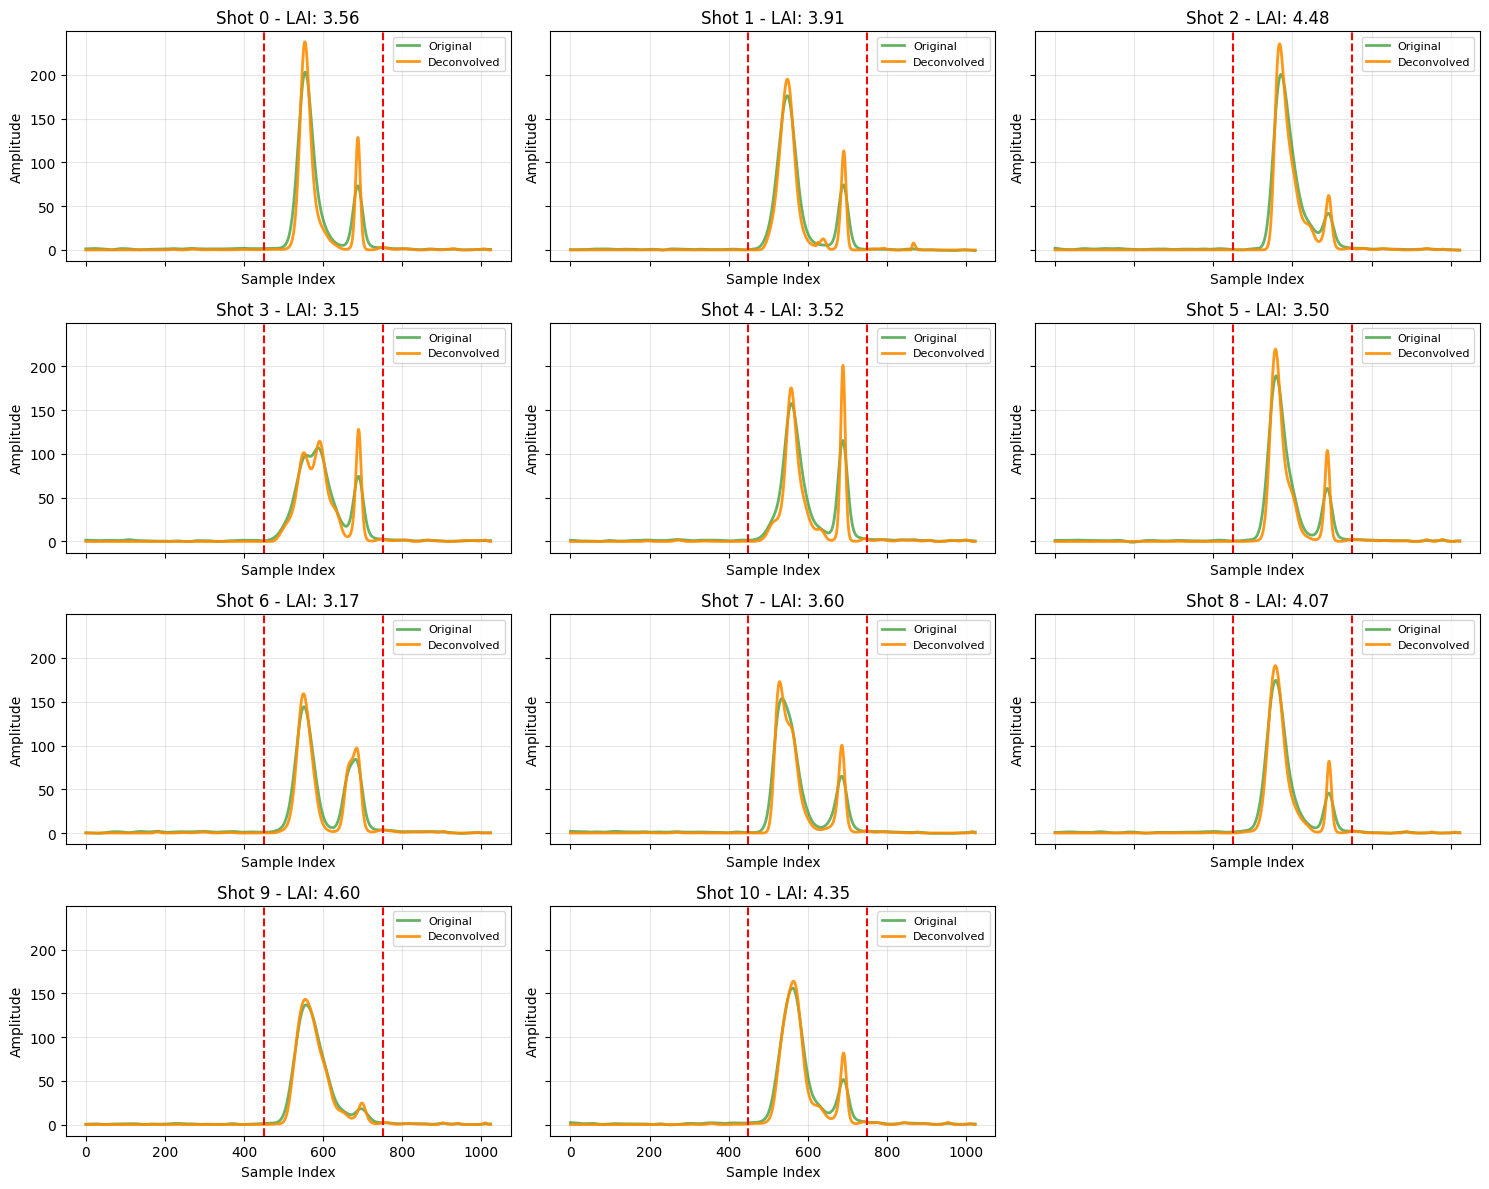

In [15]:
## Again plot deconvolved waveforms along with raw waveforms with LAI labels to see how the deconvolution worked.

fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()
for i, (wf, orig_wave, deconv) in enumerate(zip(waveforms, processed, processed_deconvolved_rl)):
    lai_value = wf['lai_value']
    axes[i].plot(orig_wave, color='g', alpha=0.6, linewidth=2, label='Original')
    axes[i].plot(deconv, color='darkorange', alpha=0.9, linewidth=2, label='Deconvolved')
    axes[i].set_title(f'Shot {i} - LAI: {lai_value:.2f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(450, color='r', linestyle='--')
    axes[i].axvline(750, color='r', linestyle='--')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize=8)
if len(processed_deconvolved_gold) < len(axes):
    for j in range(len(processed_deconvolved_gold), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [16]:
## !!Important Block: Change data here to get the results:

processed = processed_deconvolved_gold # Uncomment this to see results for 'Gold' deconvolved waveforms
# processed = processed_deconvolved_rl # Uncomment this to see results for 'RL' deconvolved waveforms
# Keep all commented to run for 'Raw' waveforms results

# Clip waveforms to bins 400-900: Since most information is in this region
clipped_waveforms = processed[:, 400:800]
processed = clipped_waveforms

In [17]:
## IGNORE THIS BLOCK:

# # RESAMPLE LVIS (1023) → SIMULATION FORMAT (1001): FOR TESTING CNN MODEL

# # Resample 1023 bins to 1001 bins
# lvis_1001 = np.array([
#     signal.resample(wf, 1001) for wf in processed
# ])

# print(f"Original LVIS shape: {processed.shape}")
# print(f"Resampled shape: {lvis_1001.shape}")

# # NOW use the EXACT same clipping as simulation
# clipped_waveforms = lvis_1001[:, 400:900]

# print(f"Final clipped shape: {clipped_waveforms.shape}")

# # Save
# np.savez('flightline_fl1.npz', 
#          waveforms=clipped_waveforms,
#          LAI=lai_values)

# print(f"Saved with same clipping (bins 400-900) as simulation!")

##### **1. Physical model**

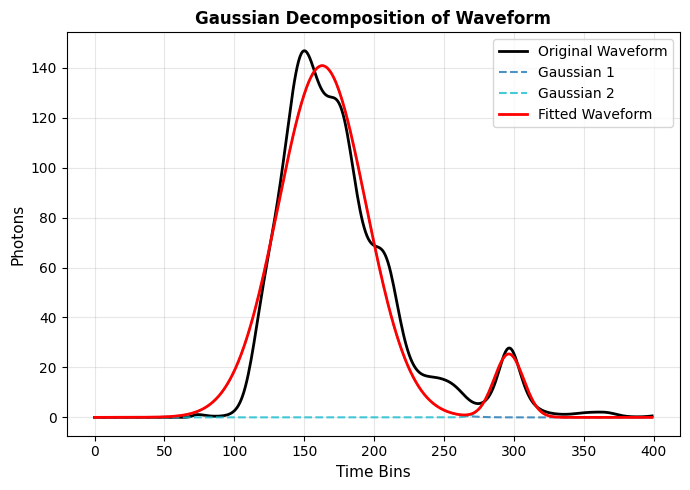


Detected Gaussian Components:
  Component 1: Amplitude=140.83, Mean=162.93, StdDev=31.28
  Component 2: Amplitude=25.40, Mean=296.48, StdDev=10.51


In [18]:
## G. Gaussian decomposition of the waveform LiDAR

def multi_gaussian(x, *params):
    """Evaluate sum of Gaussians."""
    y = np.zeros_like(x, dtype=float)
    x = x.astype(float)
    for i in range(0, len(params), 3):
        amplitude = params[i]
        mean = params[i + 1]
        stddev = params[i + 2]
        y += amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))
    return y


# Gaussian Decomposition Function
def decompose_waveform(waveform, prominence_factor=0.15, min_width=1, max_width=100):
    
    """Decompose waveform into Gaussian components."""
    x_data = np.arange(len(waveform))
    waveform = np.array(waveform, dtype=float)
    smoothed = waveform.copy()

    # Peak detection
    max_amplitude = np.max(waveform)
    prominence_threshold = max_amplitude * prominence_factor
    peaks, properties = find_peaks(
        smoothed,
        height=prominence_threshold,
        prominence=prominence_threshold * 0.5,
        distance=5,
        width=(min_width, max_width)
    )
    
    if len(peaks) == 0:
        prominence_threshold *= 0.25
        peaks, properties = find_peaks(
            smoothed,
            height=prominence_threshold,
            prominence=prominence_threshold * 0.5,
            distance=2,
            width=(min_width, max_width)
        )
    
    if len(peaks) == 0:
        return None
    
    # Initial parameters and bounds
    initial_params = []
    bounds_lower = []
    bounds_upper = []
    
    for idx, peak in enumerate(peaks):
        amplitude_guess = waveform[peak]
        mean_guess = float(peak)
        width = properties['widths'][idx] if 'widths' in properties else 2.0
        stddev_guess = max(0.25, width/2.355)
        
        initial_params.extend([amplitude_guess, mean_guess, stddev_guess])
        bounds_lower.extend([amplitude_guess * 0.1, peak - 20, 0.3])
        bounds_upper.extend([amplitude_guess * 2.5, peak + 20, 50.0])
    
    # Fit with bounds
    x_data_float = x_data.astype(float)
    
    try:
        params, _ = curve_fit(
            multi_gaussian,
            x_data_float,
            waveform,
            p0=initial_params,
            bounds=(bounds_lower, bounds_upper),
            maxfev=5000,
            ftol=1e-6
        )
        return params
    except RuntimeError as e:
        print(f"Gaussian fitting did not converge: {e}")
        return None


def plot_waveform_and_gaussians(waveform, params, title='Gaussian Decomposition of Waveform'):
    """Plot original waveform, fitted components, and their sum."""
    x_data = np.arange(len(waveform))
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(x_data, waveform, label='Original Waveform', color='black', linewidth=2)
    
    colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(params) // 3)))
    for i in range(0, len(params), 3):
        amplitude = params[i]
        mean = params[i + 1]
        stddev = params[i + 2]
        gaussian_curve = multi_gaussian(x_data, amplitude, mean, stddev)
        ax.plot(x_data, gaussian_curve, '--', label=f'Gaussian {i//3 + 1}', 
                color=colors[i//3], linewidth=1.5, alpha=0.8)
    
    fitted_waveform = multi_gaussian(x_data, *params)
    ax.plot(x_data, fitted_waveform, label='Fitted Waveform', color='red', linewidth=2, alpha=1)
    ax.set_xlabel('Time Bins', fontsize=11)
    ax.set_ylabel('Photons', fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Example usage
waveform = processed[9]
params = decompose_waveform(waveform, prominence_factor=0.15)
if params is not None:
    plot_waveform_and_gaussians(waveform, params)
    print("\nDetected Gaussian Components:")
    for i in range(0, len(params), 3):
        print(f"  Component {i//3 + 1}: Amplitude={params[i]:.2f}, Mean={params[i+1]:.2f}, StdDev={params[i+2]:.2f}")


# Determine Gap-Probability from decomposed waveforms
def gap_probability(params, rho_ratio=2.5):
    """Calculate gap probability from Gaussian parameters."""
    if params is None or len(params) == 0:
        return np.nan
    
    num_gaussians = len(params) // 3
    veg_energy = 0.0
    ground_energy = 0.0

    for i in range(num_gaussians):
        amplitude = params[i * 3]
        stddev = params[i * 3 + 2]
        
        gaussian_energy = amplitude
        
        if i == num_gaussians - 1:
            ground_energy = gaussian_energy
        else:
            veg_energy += gaussian_energy

    denominator = (rho_ratio * veg_energy) + ground_energy
    
    if denominator == 0:
        return np.nan
    
    gap_prob = ground_energy / denominator
    
    return np.clip(gap_prob, 0.0, 1.0)


# Calculate gap_probability for all waveforms
gap_data_float64 = []

for waveform in processed:
    params = decompose_waveform(waveform)
    
    if params is not None:
        gap_probab = gap_probability(params, rho_ratio=2.5)
        gap_data_float64.append(gap_probab)
    else:
        gap_data_float64.append(np.nan)

# Convert to numpy array
gap_data = np.array(gap_data_float64)

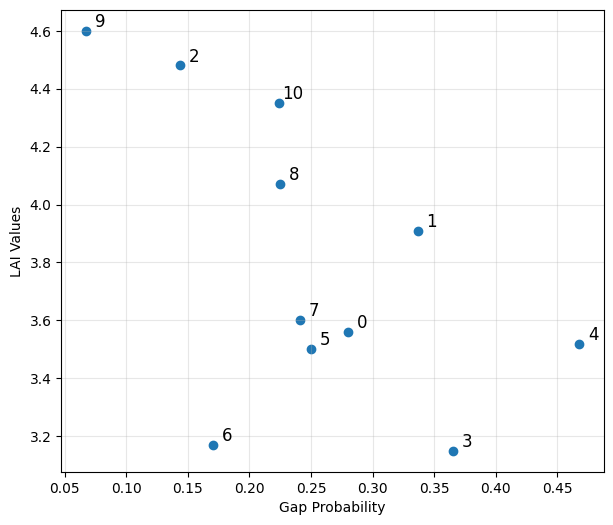

In [19]:
## Plot LAI vs -log(Gap Probability)

x = gap_data
y = lai_values

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y)
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.annotate(str(i), (xi, yi), textcoords="offset points", xytext=(10, 3), ha='center', fontsize=12)

plt.xlabel('Gap Probability')
plt.ylabel('LAI Values')
plt.grid(True, alpha=0.3)
plt.show()


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     5.944
Date:                Wed, 25 Feb 2026   Prob (F-statistic):             0.0375
Time:                        12:40:21   Log-Likelihood:                -4.8313
No. Observations:                  11   AIC:                             13.66
Df Residuals:                       9   BIC:                             14.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9005      0.393      7.371      0.0

/Users/rbcis/miniconda3/envs/main/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


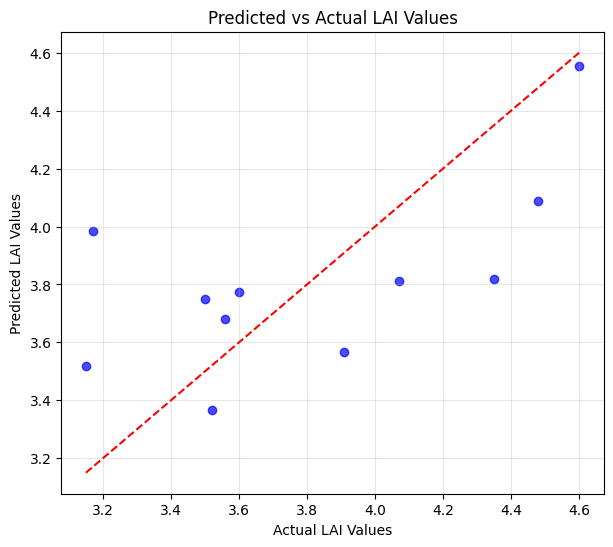

In [20]:
## H. OLS Regression: LAI vs -log(Gap Probability)

import statsmodels.api as sm

# Ensure data is in numpy array format
X = -np.log(x).reshape(1,-1)  # Gap Probability
Y = y  # LAI
X = np.column_stack(X)
X = sm.add_constant(X)  # Adds intercept term

# Fit the regression model
model = sm.OLS(Y, X).fit()

# Print model summary
print(model.summary())

## Plot predicted vs actual LAI values
predicted_lai = model.predict(X)
plt.figure(figsize=(7, 6))
plt.scatter(Y, predicted_lai, color='blue', alpha=0.7)
plt.plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--')
plt.xlabel('Actual LAI Values')
plt.ylabel('Predicted LAI Values')
plt.title('Predicted vs Actual LAI Values')
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
## Performance metrics

adj_R2 = model.rsquared_adj
R2 = model.rsquared
MSE = model.mse_resid
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(model.resid))
pearson_r = np.corrcoef(model.fittedvalues, Y)[0, 1]


# Print results
print(f"Number of Samples: {len(Y)}")
print(f"Adjusted R²: {adj_R2:.3f}")
print(f"R²: {R2:.3f}")
print(f"MSE: {MSE:.3f}")
print(f"RMSE: {RMSE:.3f}")
print(f"MAE: {MAE:.3f}")
print(f"Pearson's r: {pearson_r:.3f}")

Number of Samples: 11
Adjusted R²: 0.331
R²: 0.398
MSE: 0.172
RMSE: 0.415
MAE: 0.313
Pearson's r: 0.631


In [22]:
## I. Ridge regularized regression

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

# Prepare data
X1 = -np.log(gap_data)  # -log(Gap Probability)
Y = np.array(lai_values)  # LAI
X_gf = X1.reshape(-1, 1)
X_scaled_gf = X_gf.copy()

# Ridge Regression Model
ridge_model_gf = Ridge(alpha=0.1)
ridge_model_gf.fit(X_scaled_gf, Y)

# Predictions
Y_pred_gf = ridge_model_gf.predict(X_scaled_gf)

# Metrics
r2_gf_main = r2_score(Y, Y_pred_gf)
rmse_gf_main = np.sqrt(mean_squared_error(Y, Y_pred_gf))
pearson_r_gf_main = np.corrcoef(Y, Y_pred_gf)[0, 1]

print("="*50)
print("RIDGE REGRESSION: -log(Gap Probability) → LAI")
print("="*50)
print(f"Intercept:  {ridge_model_gf.intercept_:.4f}")
print(f"Coef:       {ridge_model_gf.coef_[0]:.4f}")
print(f"\nR²:         {r2_gf_main:.4f}")
print(f"RMSE:       {rmse_gf_main:.4f}")
print(f"Pearson r:  {pearson_r_gf_main:.4f}")

# Try different alpha values to find best
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
print(f"\nTuning Ridge alpha:")
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_scaled_gf, Y)
    Y_pred_gf = model.predict(X_scaled_gf)
    r2_gf = r2_score(Y, Y_pred_gf)
    rmse_gf = np.sqrt(mean_squared_error(Y, Y_pred_gf))
    print(f"alpha={alpha:.1f}: R²={r2_gf:.4f}, RMSE={rmse_gf:.4f}, MSE={rmse_gf**2:.4f}")

## Overfit check
loo = LeaveOneOut()
mse_cv = []

for train_idx, test_idx in loo.split(X_scaled_gf):
    X_train, X_test = X_scaled_gf[train_idx], X_scaled_gf[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    ridge_fold = Ridge(alpha=1.0)
    ridge_fold.fit(X_train, Y_train)
    y_pred = ridge_fold.predict(X_test)
    mse_cv.append((y_pred[0] - Y_test[0])**2)

rmse_loocv = np.sqrt(np.mean(mse_cv))
rmse_train = rmse_gf
print(f"\n{'='*50}")
print("OVERFITTING CHECK")
print(f"{'='*50}")
print(f"Training RMSE:  {rmse_train:.4f}")
print(f"LOOCV RMSE:     {rmse_loocv:.4f}")
print(f"LOOCV MSE:     {rmse_loocv**2:.4f}")
print(f"Difference:     {rmse_loocv - rmse_train:+.4f}")

if rmse_loocv - rmse_train < 0.1:
    print("✓ No significant overfitting")
else:
    print("⚠️  Overfitting detected")

RIDGE REGRESSION: -log(Gap Probability) → LAI
Intercept:  2.9326
Coef:       0.5907

R²:         0.3973
RMSE:       0.3756
Pearson r:  0.6307

Tuning Ridge alpha:
alpha=0.1: R²=0.3973, RMSE=0.3756, MSE=0.1410
alpha=0.5: R²=0.3882, RMSE=0.3784, MSE=0.1432
alpha=1.0: R²=0.3692, RMSE=0.3842, MSE=0.1476
alpha=2.0: R²=0.3267, RMSE=0.3970, MSE=0.1576
alpha=5.0: R²=0.2314, RMSE=0.4241, MSE=0.1799

OVERFITTING CHECK
Training RMSE:  0.4241
LOOCV RMSE:     0.4511
LOOCV MSE:     0.2035
Difference:     +0.0270
✓ No significant overfitting


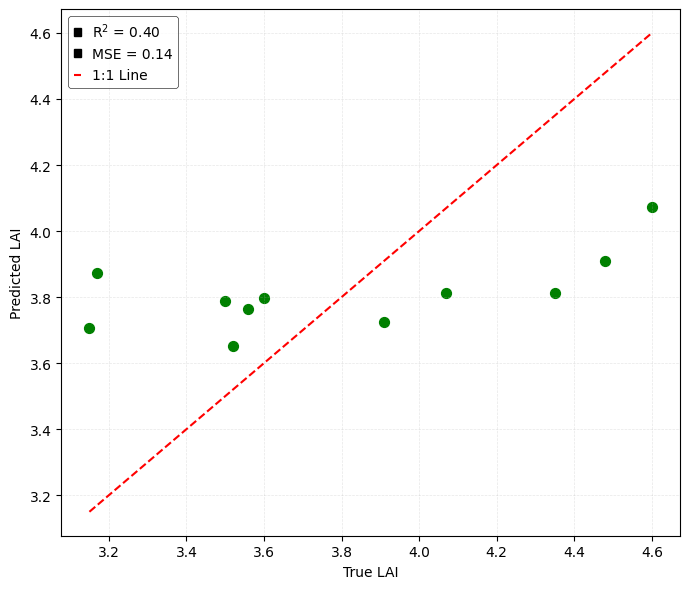

In [23]:
## Plot the performace IEEE style.

from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import matplotlib.patches as mpatches

# Set default rcParams using the extracted font name
# plt.rcParams.update({
#     "font.family": 'Times New Roman',
#     "font.size": 14,
#     "figure.dpi": 300,
#     "axes.labelsize": 14,
#     "axes.linewidth": 0.75,
#     "lines.linewidth": 0.75,
#     "legend.fontsize": 10,
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10
# })

# Plot predicted vs actual LAI values for Ridge Regression
plt.figure(figsize=(7, 6))
plt.scatter(Y, Y_pred_gf, alpha=1, color='green', s=50, edgecolors='green', linewidth=1)
line1to1 = plt.plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--', label='1:1 Line')[0]
plt.xlabel('True LAI')
plt.ylabel('Predicted LAI')
# plt.title('Ridge Regression: Predicted vs Actual LAI Values')
plt.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
pms = [
    mpatches.Patch(color='black', label=f'R$^2$ = {r2_gf_main:.2f}'),
    mpatches.Patch(color='black', label=f'MSE = {rmse_gf_main**2:.2f}'), line1to1
]
legend = plt.legend(handles=pms, loc='upper left',
                     handleheight=0.5, handlelength=0.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)
plt.tight_layout()
# plt.savefig('../../Real_LVIS_samples_test_GF_model_v2.pdf', dpi=300, bbox_inches='tight', format='pdf')
# plt.savefig('../../Real_LVIS_samples_test_GF_model_v2.png', dpi=300, bbox_inches='tight', format='png')
plt.show()


##### **2. Our Model**  
##### **See Bhatta et al. (2025) for details.**

In [24]:
## J. Calculate Centroid and Total Return Energy

waveforms = processed
centroids = []
RWE = []

# Process each waveform
for waveform in waveforms:

    # Noise removal
    waveform = np.array(waveform, dtype=np.float64)
    waveform_corrected = np.maximum(waveform - np.min(waveform), 0)
    
    # Define the position of each time bin (assuming regular sampling)
    x = np.arange(len(waveform_corrected))
    
    # Calculate total return energy (sum of intensities)
    total_energy = np.sum(waveform_corrected)
    RWE.append(total_energy)
    
    # Check if there's any energy in the waveform to avoid division by zero
    if total_energy == 0:
        centroids.append(None)
        continue
    
    # Centroid calculation (Intensity-weighted average position)
    C = np.sum(x * waveform_corrected) / total_energy
    centroids.append(C)

# Convert results to numpy arrays 
centroids = np.array(centroids)
RWE = np.array(RWE)

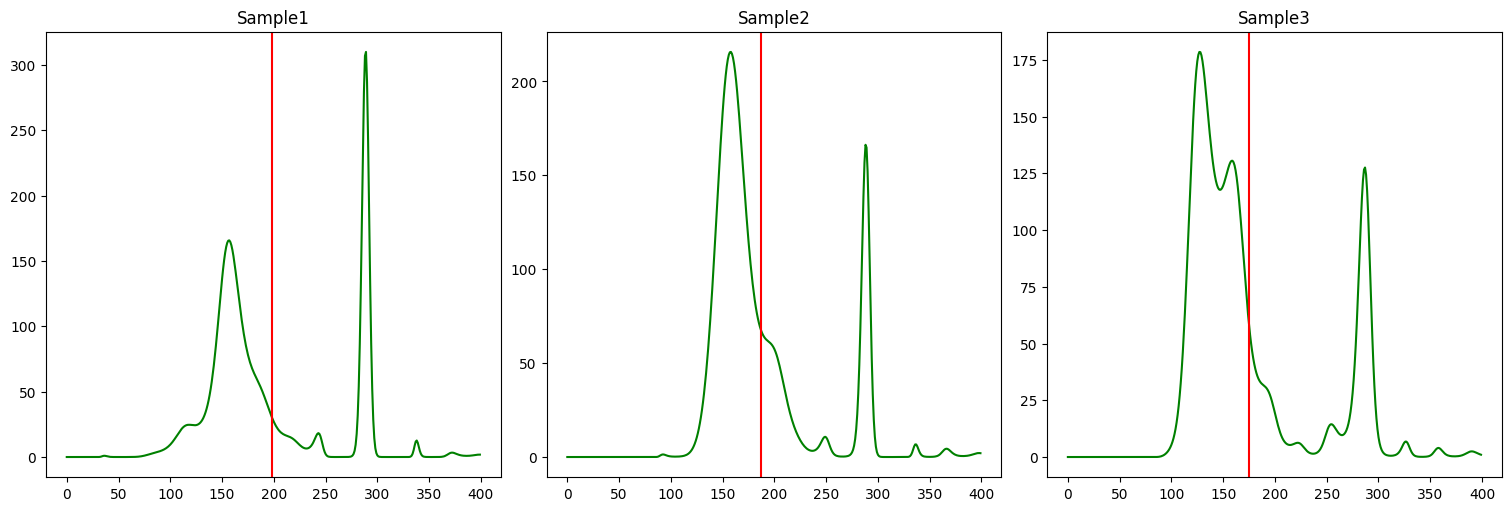

In [25]:
## Plot sample centroids

# Create a figure with 1 row and 3 columns
plot_indices = [4,5,7]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)  # figsize adjusts overall size

# Sample1
axes[0].plot(waveforms[plot_indices[0]], color='g')
axes[0].axvline(centroids[plot_indices[0]], color='r')
axes[0].set_title('Sample1')
# axes[0].set_xlim(400, 900)

# Sample2
axes[1].plot(waveforms[plot_indices[1]], color='g')
axes[1].axvline(centroids[plot_indices[1]], color='r')
axes[1].set_title('Sample2')
# axes[1].set_xlim(400, 900)

# Sample3
axes[2].plot(waveforms[plot_indices[2]], color='g')
axes[2].axvline(centroids[plot_indices[2]], color='r')
axes[2].set_title('Sample3')
# axes[2].set_xlim(400, 900)

plt.show()

In [26]:
## K. Calculate Gini coefficient metric

def calculate_gini_coeff(y, interval_width=0.05):
    
    # Ensure F(y) starts at 0 and ends at 1
    y = np.array(y)
    if y[0] != 0: y = np.insert(y, 0, 0)
    if y[-1] != 1: y = np.append(y, 1)
    
    k = len(y)  # Total bins
    n = k - 1   # Number of intervals (20 for 5% bins)
    correction_factor = n / (n - 1)  # Sample bias correction
    
    # Compute area under the Lorenz curve 
    area = 0
    for i in range(1, k):
        area += ((y[i] + y[i-1]) / 2) * interval_width
    
    # Compute Gini Coefficient 
    gini_coefficient = correction_factor * (0.5 - area)
    
    return gini_coefficient

# Initialize empty lists 
Gini_coefficients = [] 

# Loop over all waveforms
for waveform in waveforms:
    waveform_corrected = np.maximum(waveform - np.min(waveform), 0)
    peaks, _ = find_peaks(waveform_corrected, height=np.max(waveform_corrected) * 0.05)
    derivative = np.diff(waveform_corrected)
    
    # Identify first and last inflection points
    first_inflection_point = None
    last_inflection_point = None

    # Last inflection point (end of last peak)
    if len(peaks) > 0:
        last_peak = peaks[-1]
        for i in range(last_peak + 1, len(derivative)):
            if derivative[i] == 0.0:
                last_inflection_point = i
                break

    # First inflection point (start of first peak)
    if len(peaks) > 0:
        for i in range(len(derivative)):
            if derivative[i] > 0.0:
                first_inflection_point = i
                break

    # Filter the waveform between the first and last inflection points
    if first_inflection_point is not None and last_inflection_point is not None:
        waveform_clipped = waveform_corrected[first_inflection_point:last_inflection_point+1]
    else:
        waveform_clipped = waveform_corrected

    # Reverse the waveform
    waveform_reversed = waveform_clipped[::-1]
    height_bins = np.arange(0, len(waveform_reversed)) * 0.15  # Vertical resolution

    # Compute cumulative energy and total energy
    cumulative_energy = np.cumsum(waveform_reversed)
    total_energy = np.sum(waveform_reversed)

    # Compute relative heights
    s = 0.05  # Sample size %
    RH_levels = np.arange(0, 1 + s, s)
    RHs = np.array([np.searchsorted(cumulative_energy, level * total_energy) for level in RH_levels]) 
    cumulative_energy_RH = [np.sum(waveform_reversed[:rh]) for rh in RHs]

    # Lorenz Curve
    lorentz_height_values = np.cumsum(RHs * 0.15) / np.max(np.cumsum(RHs * 0.15))
    lorentz_energy_values = cumulative_energy_RH / np.max(cumulative_energy_RH)

    # Calculate Gini Coefficient and Lorentz Entropy
    GC = calculate_gini_coeff(lorentz_height_values, s)
    
    # Append the results
    Gini_coefficients.append(GC)

# Convert numpy arrays
GC = np.array(Gini_coefficients)

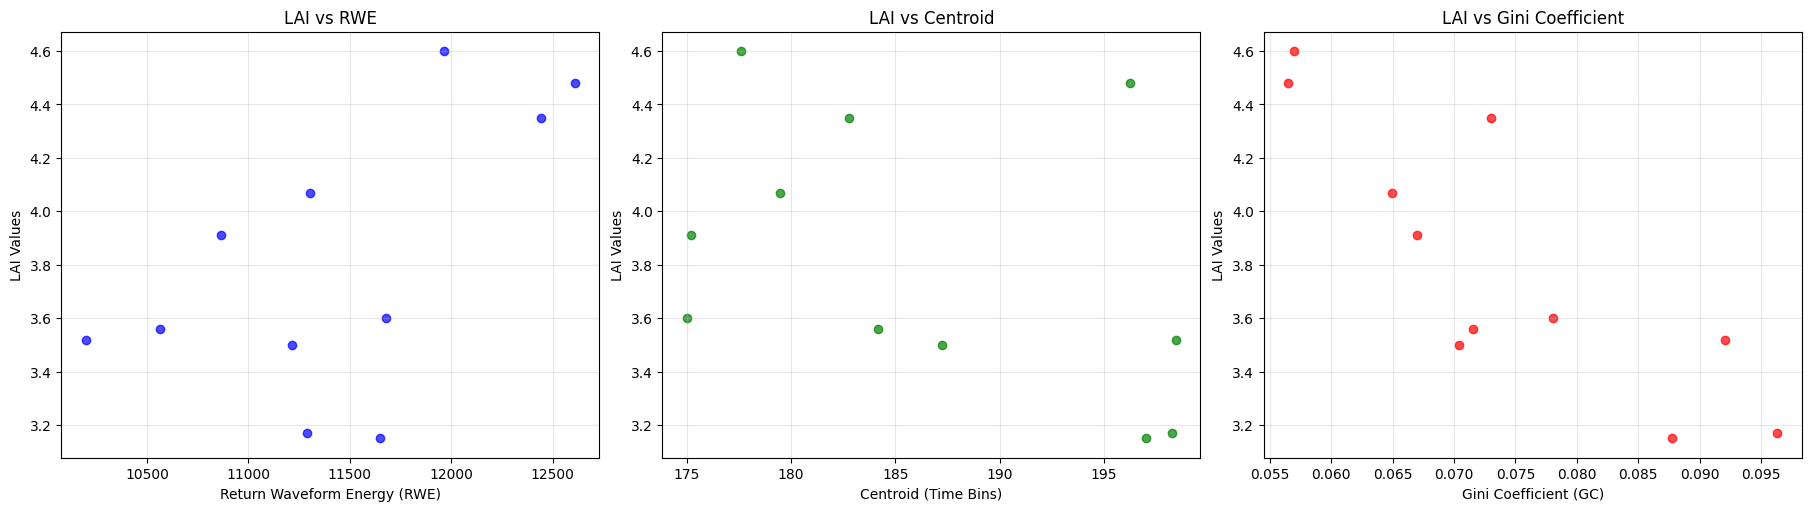

In [27]:
## Plot LAI vs RWE, Centroid, Gini Coefficient

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].scatter(RWE, lai_values, color='b', alpha=0.7)
axes[0].set_xlabel('Return Waveform Energy (RWE)')
axes[0].set_ylabel('LAI Values')
axes[0].set_title('LAI vs RWE')
axes[0].grid(True, alpha=0.3)
axes[1].scatter(centroids, lai_values, color='g', alpha=0.7)
axes[1].set_xlabel('Centroid (Time Bins)')
axes[1].set_ylabel('LAI Values')
axes[1].set_title('LAI vs Centroid')
axes[1].grid(True, alpha=0.3)
axes[2].scatter(GC, lai_values, color='r', alpha=0.7)
axes[2].set_xlabel('Gini Coefficient (GC)')
axes[2].set_ylabel('LAI Values')
axes[2].set_title('LAI vs Gini Coefficient')
axes[2].grid(True, alpha=0.3)
plt.show()

Pearson correlation between LAI and RWE: 0.587
Pearson correlation between LAI and Centroid: -0.430
Pearson correlation between LAI and Gini Coefficient: -0.835


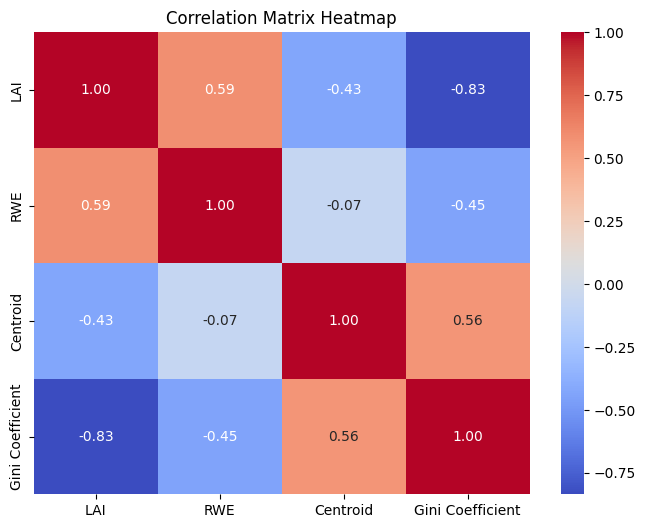

In [28]:
## L. Correlation between LAI and RWE, Centroid, Gini Coefficient

from scipy.stats import pearsonr

corr_RWE, _ = pearsonr(RWE, lai_values)
corr_centroid, _ = pearsonr(centroids, lai_values)
corr_GC, _ = pearsonr(GC, lai_values)

print(f"Pearson correlation between LAI and RWE: {corr_RWE:.3f}")
print(f"Pearson correlation between LAI and Centroid: {corr_centroid:.3f}")
print(f"Pearson correlation between LAI and Gini Coefficient: {corr_GC:.3f}")

## Correlation Matrix Heatmap
data = {
    'LAI': lai_values,
    'RWE': RWE,
    'Centroid': centroids,
    'Gini Coefficient': GC
}
df = pd.DataFrame(data)
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()


In [29]:
## M. OLS model

# Ensure data is in numpy array format
X1 = GC  # GC
X2 = np.log(centroids)  # log(C)
X3 = np.log(RWE)  # log(RWE)
Y = lai_values  # LAI
X = np.column_stack((X1, X2, X3))
X = sm.add_constant(X) 
model = sm.OLS(Y, X).fit()

# Print model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     6.945
Date:                Wed, 25 Feb 2026   Prob (F-statistic):             0.0166
Time:                        12:40:22   Log-Likelihood:              -0.027976
No. Observations:                  11   AIC:                             8.056
Df Residuals:                       7   BIC:                             9.648
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.3674     17.776     -0.696      0.5

/Users/rbcis/miniconda3/envs/main/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [30]:
## Performance metrics for our model

adj_R2 = model.rsquared_adj
R2 = model.rsquared
MSE = model.mse_resid
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(model.resid))
pearson_r = np.corrcoef(model.fittedvalues, Y)[0, 1]

# Print results
print(f"Number of Samples: {len(Y)}")
print(f"Adjusted R²: {adj_R2:.3f}")
print(f"R²: {R2:.3f}")
print(f"MSE: {MSE:.3f}")
print(f"RMSE: {RMSE:.3f}")
print(f"MAE: {MAE:.3f}")
print(f"Pearson r: {pearson_r:.3f}")

Number of Samples: 11
Adjusted R²: 0.641
R²: 0.749
MSE: 0.092
RMSE: 0.304
MAE: 0.186
Pearson r: 0.865


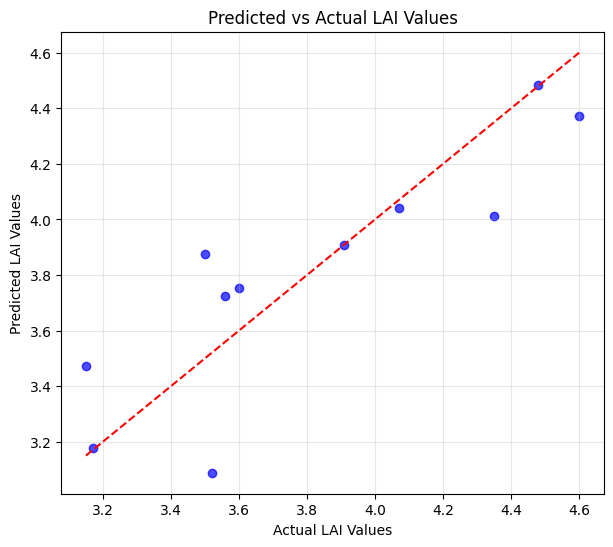

In [31]:
## Plot predicted vs actual LAI values

predicted_lai = model.predict(X)
plt.figure(figsize=(7, 6))
plt.scatter(Y, predicted_lai, color='blue', alpha=0.7)
plt.plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--')
plt.xlabel('Actual LAI Values')
plt.ylabel('Predicted LAI Values')
plt.title('Predicted vs Actual LAI Values')
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
## N. Ridge regularized regression for our model

# Prepare data
X1 = np.array(GC)
X2 = np.log(np.array(centroids))
X3 = np.log(np.array(RWE))
Y = np.array(lai_values)
scaler = StandardScaler()
X = np.column_stack((X1, X2, X3))
X_scaled = scaler.fit_transform(X)

# Ridge regression
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_scaled, Y)

# Predictions
Y_pred = ridge_model.predict(X_scaled)

# Metrics
r2_empirical = r2_score(Y, Y_pred)
rmse_empirical = np.sqrt(mean_squared_error(Y, Y_pred))
pearson_r_empirical = np.corrcoef(Y, Y_pred)[0, 1]

print("="*50)
print("RIDGE REGRESSION (Regularized)")
print("="*50)
print(f"Intercept:  {ridge_model.intercept_:.4f}")
print(f"Coef X1:    {ridge_model.coef_[0]:.4f}")
print(f"Coef X2:    {ridge_model.coef_[1]:.4f}")
print(f"Coef X3:    {ridge_model.coef_[2]:.4f}")
print(f"\nR²:         {r2_empirical:.4f}")
print(f"RMSE:       {rmse_empirical:.4f}")
print(f"MSE:       {rmse_empirical**2:.4f}")
print(f"Pearson r:  {pearson_r_empirical:.4f}")

# Try different alpha values
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
print(f"\nTuning Ridge alpha:")
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_scaled, Y)
    Y_pred = model.predict(X_scaled)
    r2 = r2_score(Y, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    print(f"  alpha={alpha:.1f}: R²={r2:.4f}, RMSE={rmse:.4f}, MSE={rmse**2:.4f}")

# Overfit check
loo = LeaveOneOut()
mse_cv = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    ridge_fold = Ridge(alpha=1.0)
    ridge_fold.fit(X_train, Y_train)
    y_pred = ridge_fold.predict(X_test)
    mse_cv.append((y_pred[0] - Y_test[0])**2)

rmse_loocv = np.sqrt(np.mean(mse_cv))
rmse_train = rmse
print(f"\n{'='*50}")
print("OVERFITTING CHECK")
print(f"{'='*50}")
print(f"Training RMSE:  {rmse_train:.4f}")
print(f"LOOCV RMSE:     {rmse_loocv:.4f}")
print(f"LOOCV MSE:     {rmse_loocv**2:.4f}")
print(f"Difference:     {rmse_loocv - rmse_train:+.4f}")
if rmse_loocv - rmse_train < 0.1:
    print("✓ No significant overfitting")
else:
    print("⚠️  Overfitting detected")

RIDGE REGRESSION (Regularized)
Intercept:  3.8100
Coef X1:    -0.3414
Coef X2:    -0.0069
Coef X3:    0.1246

R²:         0.7485
RMSE:       0.2426
MSE:       0.0589
Pearson r:  0.8652

Tuning Ridge alpha:
  alpha=0.1: R²=0.7485, RMSE=0.2426, MSE=0.0589
  alpha=0.5: R²=0.7472, RMSE=0.2432, MSE=0.0592
  alpha=1.0: R²=0.7441, RMSE=0.2447, MSE=0.0599
  alpha=2.0: R²=0.7349, RMSE=0.2491, MSE=0.0620
  alpha=5.0: R²=0.6987, RMSE=0.2655, MSE=0.0705

OVERFITTING CHECK
Training RMSE:  0.2655
LOOCV RMSE:     0.3779
LOOCV MSE:     0.1428
Difference:     +0.1123
⚠️  Overfitting detected


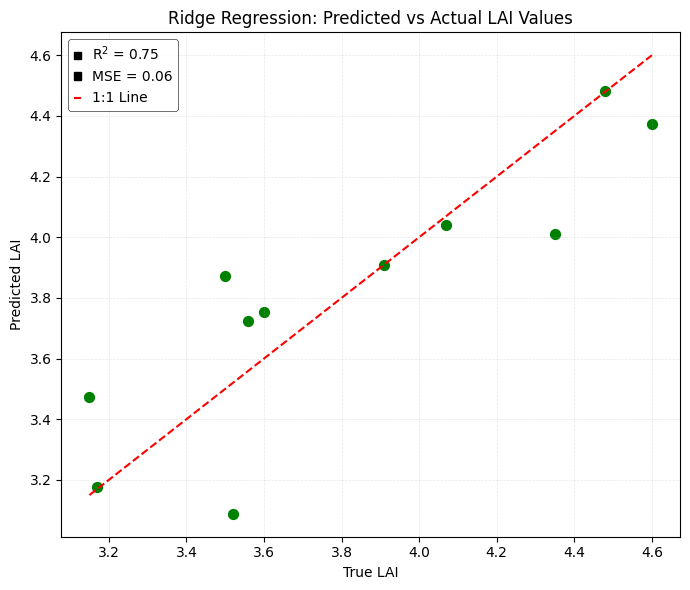

In [33]:
## Plot predicted vs actual LAI values for Ridge Regression

plt.figure(figsize=(7, 6))
Y_pred = predicted_lai
plt.scatter(Y, Y_pred, alpha=1, color='green', s=50, edgecolors='green', linewidth=1)
line1to1 = plt.plot([min(Y), max(Y)], [min(Y), max(Y)], color='red', linestyle='--', label='1:1 Line')[0]
plt.xlabel('True LAI')
plt.ylabel('Predicted LAI')
plt.title('Ridge Regression: Predicted vs Actual LAI Values')
plt.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

pms = [
    mpatches.Patch(color='black', label=f'R$^2$ = {r2_empirical:.2f}'),
    mpatches.Patch(color='black', label=f'MSE = {rmse_empirical**2:.2f}'), line1to1
]
legend = plt.legend(handles=pms, loc='upper left',
                     handleheight=0.5, handlelength=0.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()
# plt.savefig('../../Real_LVIS_samples_test_empirical_model_v2.pdf', dpi=600, bbox_inches='tight', format='pdf')
# plt.savefig('../../Real_LVIS_samples_test_empirical_model_v2.png', dpi=600, bbox_inches='tight', format='png')
plt.show()